# 03b — Random Forest (Benchmark Model)

## Role of This Model

Random Forest is used as a **benchmark** — not as the primary model.

The question we are answering here is:
> *Does increased model complexity materially improve decision quality over Logistic Regression?*

If the improvement is marginal, Logistic Regression remains justified as the primary model — because interpretability and transparency have real business value.

| Property | Logistic Regression | Random Forest |
|---|---|---|
| Interpretability | High (coefficients) | Low (black box) |
| Predictive power | Moderate | Higher |
| Feature importance | Coefficients | Gini importance |
| Overfitting risk | Low | Medium |

---

## 1. Imports and Data Loading

In [2]:
import sys
sys.path.append('../../src')

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

from modeling import (
    split_data,
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curve,
    print_metrics_table,
    save_model,
)

df = pd.read_csv('../../data/featured_churn.csv')

print('Loaded featured data.')
print('Shape:', df.shape)

Loaded featured data.
Shape: (7032, 32)


---
## 2. Train / Test Split

In [3]:
X_train, X_test, y_train, y_test = split_data(df)

print(f'Training set : {X_train.shape[0]} rows  |  Churn rate: {y_train.mean()*100:.1f}%')
print(f'Test set     : {X_test.shape[0]} rows  |  Churn rate: {y_test.mean()*100:.1f}%')

Training set : 5625 rows  |  Churn rate: 26.6%
Test set     : 1407 rows  |  Churn rate: 26.6%


---
## 3. Train Random Forest

In [4]:
rf_model = RandomForestClassifier(
    n_estimators=100,          # 100 decision trees
    class_weight='balanced',   # handles class imbalance
    random_state=42,
    n_jobs=-1                  # use all CPU cores
)

rf_model.fit(X_train, y_train)
print('Model trained successfully.')

Model trained successfully.


---
## 4. Evaluation

In [5]:
metrics = evaluate_model(rf_model, X_test, y_test)
print_metrics_table(metrics, model_name='Random Forest')


  Random Forest — Evaluation Results
  ROC-AUC     : 0.8134  ◄ primary
  Recall      : 0.4813  ◄ business priority
  Precision   : 0.6207
  F1          : 0.5422
  Accuracy    : 0.7839



---
## 5. Confusion Matrix

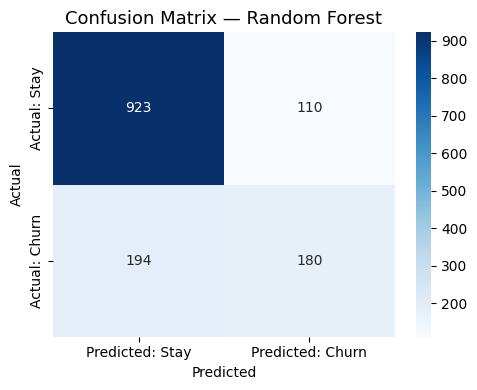

  True Positives  (caught churners):  180
  False Negatives (missed churners):  194  ← business cost
  False Positives (wrong alerts):     110
  True Negatives  (correct stays):    923


In [6]:
plot_confusion_matrix(rf_model, X_test, y_test, model_name='Random Forest')

---
## 6. ROC Curve

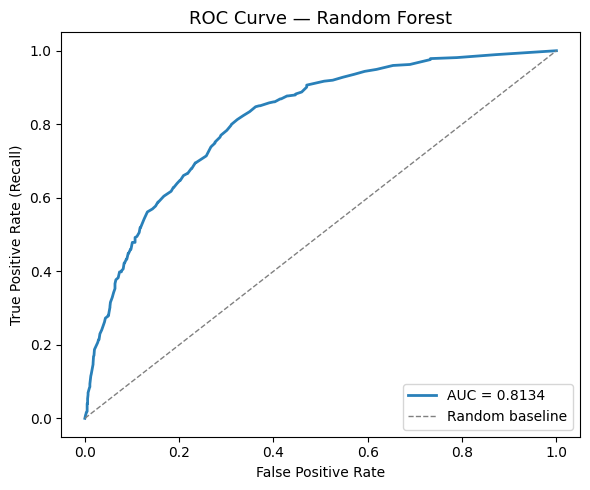

In [7]:
plot_roc_curve(rf_model, X_test, y_test, model_name='Random Forest')

---
## 7. Feature Importance

Random Forest provides Gini-based feature importance — a different lens than Logistic Regression coefficients.
Comparing both gives a more robust understanding of which features truly drive churn.

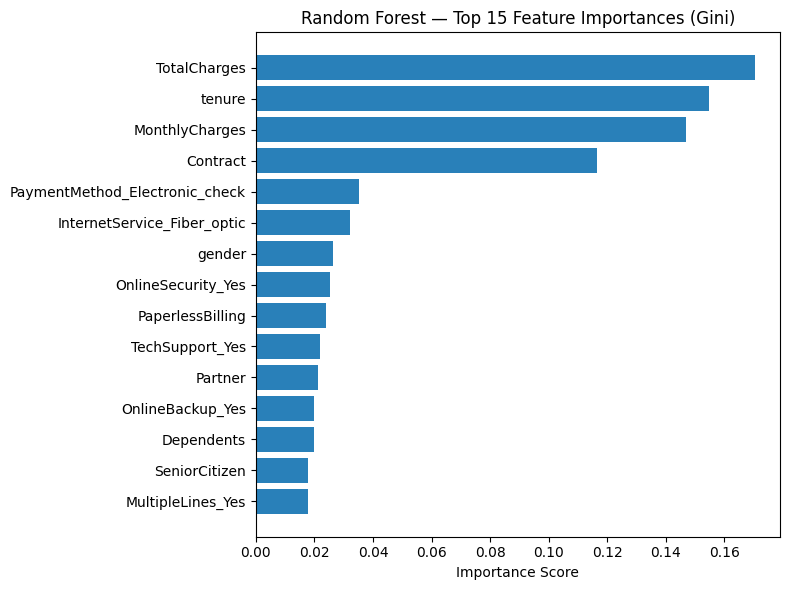


Top 10 most important features:
                       Feature  Importance
                  TotalCharges    0.170442
                        tenure    0.154564
                MonthlyCharges    0.146740
                      Contract    0.116361
PaymentMethod_Electronic_check    0.035278
   InternetService_Fiber_optic    0.032237
                        gender    0.026175
            OnlineSecurity_Yes    0.025223
              PaperlessBilling    0.023926
               TechSupport_Yes    0.021885


In [8]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='#2980b9')
ax.set_title('Random Forest — Top 15 Feature Importances (Gini)', fontsize=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 most important features:')
print(importance_df.head(10).to_string(index=False))

---
## 8. Save Model

In [9]:
save_model(rf_model, 'random_forest', folder='../../models')
print('Random Forest model saved. Proceed to 03c_gradient_boosting.ipynb')

Model saved to: ../../models\random_forest.pkl
Random Forest model saved. Proceed to 03c_gradient_boosting.ipynb


---
## Summary

Random Forest is a stronger predictive model than Logistic Regression but sacrifices interpretability.

Key question to carry into the final comparison:
> Is the AUC and Recall improvement over Logistic Regression large enough to justify losing coefficient transparency?

This will be answered in `04_evaluation.ipynb`.